# Time-series forecasting (PyTorch)

**Time-series forecasting** is an essential task in many real-world applications, such as weather forecasting, and sales projections, etc. In this lab, we will explore how to build a time-series forecasting model using LSTM to predict future Tesla stock prices based on past patterns and trends. By leveraging historical market data, the model forecasts stock prices, allowing stakeholders to anticipate trends and optimize their investment strategies in the volatile stock market.

# Learning Objectives

By the end of this lab, you should be able to:

- explain what makes time-series forecasting different from standard supervised learning
- prepare sequential data for an LSTM using a sliding-window approach
- build and train a stacked LSTM model in PyTorch
- understand the role of `return_sequences` (Keras) vs. selecting the last time step (PyTorch) when stacking recurrent layers
- interpret training loss curves for a regression task
- evaluate a forecasting model using RMSE
- apply the same pipeline to a new dataset (mini-project)

# **Importing Necessary Libraries**

In [ ]:
import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.11.0+cpu
Using device: cpu


# **Reading The Data**
We'll use Tesla's stock prices obtained from a CSV file named TSLA.csv. The CSV file should contain daily stock prices with at least the following columns: Date, Open, High, Low, Close, Volume, but we only focus on the 5th column (Close), which holds the  Close prices..

In [ ]:
import os
import urllib.request
import zipfile

# Tesla daily stock prices, shipped in the repository's data/ folder (downloaded from GitHub when running on Colab)
local_zip = "../../data/tesla_stock_prices.csv.zip"
if not os.path.exists(local_zip):
    local_zip = "tesla_stock_prices.csv.zip"
    urllib.request.urlretrieve("https://raw.githubusercontent.com/MissawB/deep-learning-pytorch/main/data/tesla_stock_prices.csv.zip", local_zip)

with zipfile.ZipFile(local_zip, 'r') as zip_ref:
    zip_ref.extractall("Tesla")

In [ ]:
df = pd.read_csv("Tesla/Tesla.csv" , parse_dates=True , index_col="Date")
df.head()

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,18766300,23.889999
2010-06-30,25.790001,30.42,23.299999,23.830000,17187100,23.830000
2010-07-01,25.000000,25.92,20.270000,21.959999,8218800,21.959999
2010-07-02,23.000000,23.10,18.709999,19.200001,5139800,19.200001
2010-07-06,20.000000,20.00,15.830000,16.110001,6866900,16.110001


In [ ]:
df.describe()

,Open,High,Low,Close,Volume,Adj Close
count,1692.000000,1692.000000,1692.000000,1692.000000,1.692000e+03,1692.000000
mean,132.441572,134.769698,129.996223,132.428658,4.270741e+06,132.428658
std,94.309923,95.694914,92.855227,94.313187,4.295971e+06,94.313187
min,16.139999,16.629999,14.980000,15.800000,1.185000e+05,15.800000
25%,30.000000,30.650000,29.215000,29.884999,1.194350e+06,29.884999
50%,156.334999,162.370002,153.150002,158.160004,3.180700e+06,158.160004
75%,220.557495,224.099999,217.119999,220.022503,5.662100e+06,220.022503
max,287.670013,291.420013,280.399994,286.040009,3.716390e+07,286.040009


In [ ]:
print(df.shape)
df.info()

(1692, 6)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1692 entries, 2010-06-29 to 2017-03-17
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1692 non-null   float64
 1   High       1692 non-null   float64
 2   Low        1692 non-null   float64
 3   Close      1692 non-null   float64
 4   Volume     1692 non-null   int64  
 5   Adj Close  1692 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 92.5 KB


# **Data Visualization**

<Axes: >

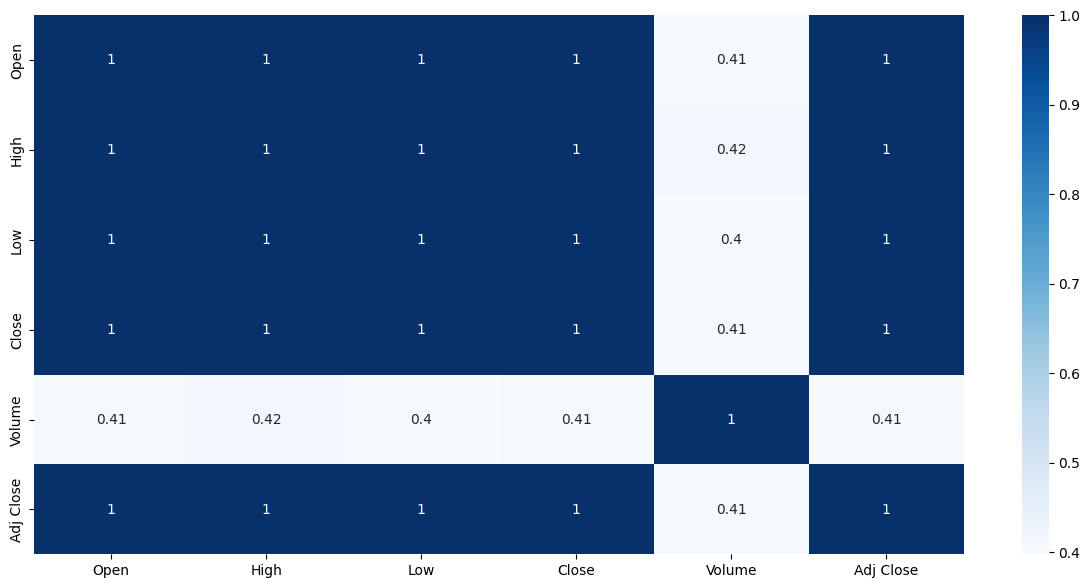

In [ ]:
plt.figure(figsize=(15, 7))
sns.heatmap(df.corr(),cbar=True,annot=True,cmap='Blues')

Text(0, 0.5, 'Close Price USD')

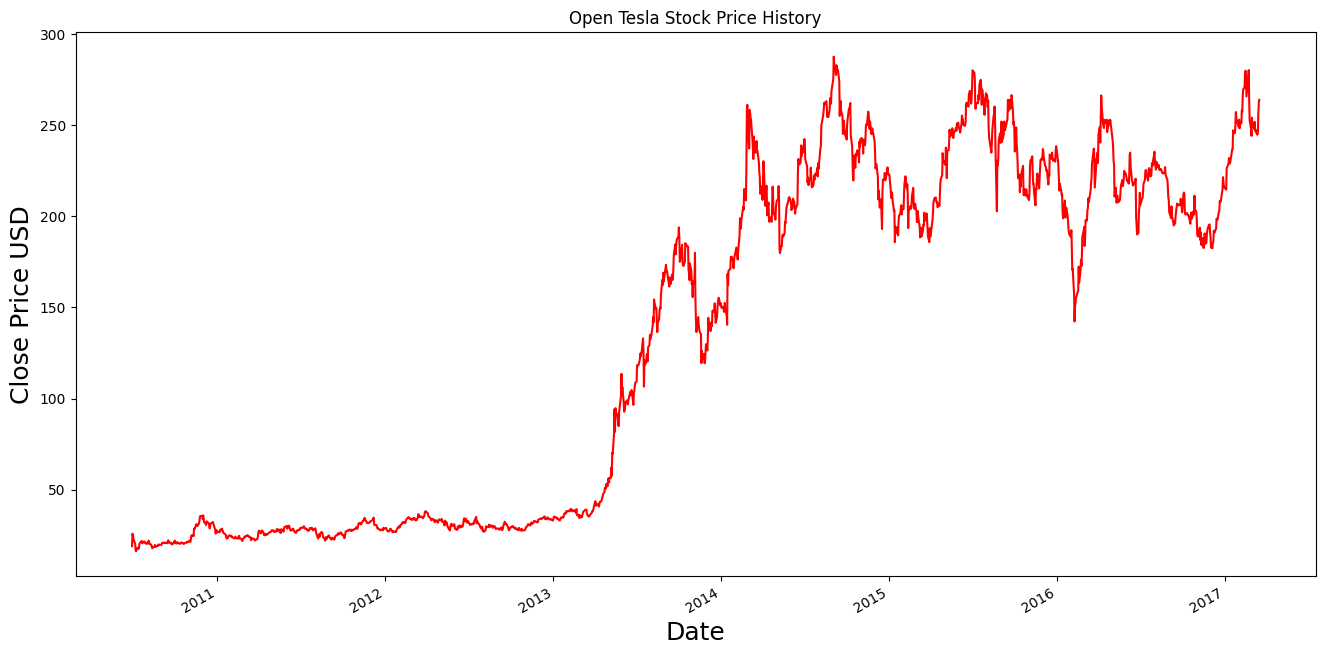

In [ ]:
df["Open"].plot(figsize=(16,8) , color='red')
plt.title("Open Tesla Stock Price History")
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD', fontsize = 18)

[ 16.139999  16.4       17.389999 ... 282.98999  284.01001  287.670013] This is the Sorted data of Open Share Price


Text(0, 0.5, 'Frequency')

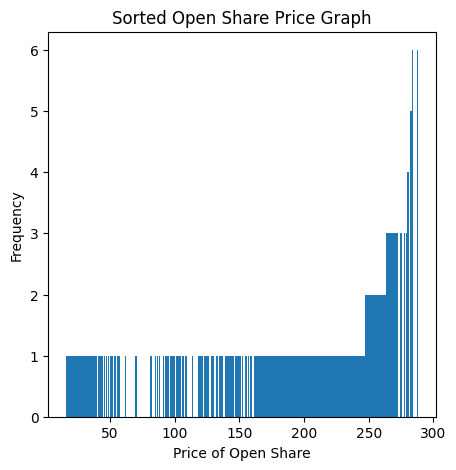

In [ ]:
print(np.sort(df['Open']), "This is the Sorted data of Open Share Price")
plt.figure(figsize=(5,5))
plt.bar(list(np.sort(df['Open'].value_counts().keys())), list(np.sort(df['Open'].value_counts())))
plt.title("Sorted Open Share Price Graph")
plt.xlabel("Price of Open Share")
plt.ylabel("Frequency")

# **Data Preprocessing**

In [ ]:
df.isna().any()

,0
Open,False
High,False
Low,False
Close,False
Volume,False
Adj Close,False


**Choosing Prediction Column**

In [ ]:
dataset = df["Open"]
dataset = pd.DataFrame(dataset)

data = dataset.values

data.shape

(1692, 1)

**Normalizing Data**
Since neural networks work better with normalized data, we'll use the MinMaxScaler to scale the values between 0 and 1. This ensures that all values are on the same scale, which accelerates the learning process and prevents some features from dominating others.

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

**Splitting the Data**

In [ ]:
# 75% to Train , 25% to Test
train_size = int(len(data)*.75)
test_size = len(data) - train_size

print("Train Size :",train_size,"Test Size :",test_size)

train_data = scaled_data[ :train_size , 0:1 ]
test_data = scaled_data[ train_size-60: , 0:1 ]

Train Size : 1269 Test Size : 423


In [ ]:
train_data.shape,test_data.shape

((1269, 1), (483, 1))

# **Creating training set**
To train the LSTM, we need to prepare the dataset using a sliding window approach. This method creates input-output pairs, where the input is a sequence of previous time steps, and the output is the next time step's value. For example, if the look_back parameter is 60, the model will predict the 61th value using the previous 60 values.

In [ ]:
# Creating a Training set with 60 time-steps and 1 output
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

In [ ]:
# Convert to numpy array
x_train, y_train = np.array(x_train), np.array(y_train)

**Reshape Input Data for LSTM**
LSTMs expect a 3D input of the form [samples, time steps, features]. The sliding window data created in the previous step needs to be reshaped accordingly.

> Note: `torch.nn.LSTM` uses this same `[batch, time steps, features]` ordering as long as we create it with `batch_first=True` (done below), so this reshape step is identical to the Keras version.

In [ ]:
# Reshape input to be [samples, time steps, features]
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

Here:

* Samples: The number of training instances.
* Time steps: The look_back value, representing how many past observations the model considers when making predictions.
* Features: The number of variables (in this case, only 1 because we are working with a univariate time series).

In [ ]:
x_train.shape , y_train.shape

((1209, 60, 1), (1209,))

# **Building LSTM Model**
Now we will define an `nn.Module` in PyTorch with two LSTM layers followed by three Dense (`nn.Linear`) layers.

First LSTM layer: returns the **full sequence** of hidden states (Keras `return_sequences=True`) because we are stacking multiple LSTM layers — in PyTorch this is the default behavior of `nn.LSTM`, which always outputs the full sequence; we simply pass it on to the next layer.
Second LSTM layer: we only keep the **last time step's output** (Keras `return_sequences=False` equivalent — `output[:, -1, :]` in PyTorch), which is passed to 3 Dense layers to make predictions.
Last Dense layer: outputs the predicted Open price.

In [ ]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden1=50, hidden2=64):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size=input_size, hidden_size=hidden1, batch_first=True)
        self.lstm2 = nn.LSTM(input_size=hidden1, hidden_size=hidden2, batch_first=True)
        self.dense1 = nn.Linear(hidden2, 32)
        self.dense2 = nn.Linear(32, 16)
        self.dense3 = nn.Linear(16, 1)

    def forward(self, x):
        # x: (batch, time_steps, features)
        out, _ = self.lstm1(x)          # (batch, time_steps, hidden1) - full sequence, like return_sequences=True
        out, _ = self.lstm2(out)        # (batch, time_steps, hidden2)
        out = out[:, -1, :]             # keep only the last time step, like return_sequences=False
        out = self.dense1(out)
        out = self.dense2(out)
        out = self.dense3(out)
        return out


model = LSTMForecaster(input_size=1, hidden1=50, hidden2=64).to(device)
print(model)

LSTMForecaster(
  (lstm1): LSTM(1, 50, batch_first=True)
  (lstm2): LSTM(50, 64, batch_first=True)
  (dense1): Linear(in_features=64, out_features=32, bias=True)
  (dense2): Linear(in_features=32, out_features=16, bias=True)
  (dense3): Linear(in_features=16, out_features=1, bias=True)
)


**Compile the Model**
Next, we compile the model using the Adam optimizer and mean squared error (MSE) as the loss function. MSE is commonly used for regression tasks like time-series forecasting.

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 42,921
Trainable parameters: 42,921


**Train the Model**
We train the model for 100 epochs with a batch size of 32. Each epoch allows the model to see the entire dataset, helping it learn the patterns in the data. Training for a larger number of epochs is often necessary for models to capture time-series patterns effectively.

> The original notebook monitors the **training loss** for early stopping (`monitor='loss'`, no validation split passed to `.fit()`). We reproduce that exactly: early stopping and `restore_best_weights` are based on the training loss, not a held-out validation set.

In [ ]:
import copy

def train_with_early_stopping(model, x_train_data, y_train_data, criterion, optimizer, device,
                                epochs=100, batch_size=32, patience=10):
    x_tensor = torch.tensor(x_train_data, dtype=torch.float32)
    y_tensor = torch.tensor(y_train_data, dtype=torch.float32).unsqueeze(1)

    train_dataset = TensorDataset(x_tensor, y_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    history = {"loss": [], "mean_squared_error": []}
    best_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            total += xb.size(0)

        epoch_loss = running_loss / total
        # metrics=["mean_squared_error"] in the original notebook is identical to the MSE loss itself
        history["loss"].append(epoch_loss)
        history["mean_squared_error"].append(epoch_loss)

        print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.6f}")

        if epoch_loss < best_loss:
            best_loss = epoch_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping triggered after epoch {epoch+1}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)  # restore_best_weights=True equivalent

    return history


# Fitting the LSTM to the Training set
history = train_with_early_stopping(model, x_train, y_train, criterion, optimizer, device,
                                     epochs=100, batch_size=32, patience=10)

Epoch 1/100 - loss: 0.084084
Epoch 2/100 - loss: 0.005543
Epoch 3/100 - loss: 0.001862
Epoch 4/100 - loss: 0.001734
Epoch 5/100 - loss: 0.001374
Epoch 6/100 - loss: 0.001117
Epoch 7/100 - loss: 0.000974
Epoch 8/100 - loss: 0.000910
Epoch 9/100 - loss: 0.000860
Epoch 10/100 - loss: 0.000935
Epoch 11/100 - loss: 0.000915
Epoch 12/100 - loss: 0.000750
Epoch 13/100 - loss: 0.000820
Epoch 14/100 - loss: 0.000724
Epoch 15/100 - loss: 0.000733
Epoch 16/100 - loss: 0.000747
Epoch 17/100 - loss: 0.000965
Epoch 18/100 - loss: 0.000767
Epoch 19/100 - loss: 0.000738
Epoch 20/100 - loss: 0.000630
Epoch 21/100 - loss: 0.000598
Epoch 22/100 - loss: 0.000596
Epoch 23/100 - loss: 0.000657
Epoch 24/100 - loss: 0.000591
Epoch 25/100 - loss: 0.000543
Epoch 26/100 - loss: 0.000575
Epoch 27/100 - loss: 0.000534
Epoch 28/100 - loss: 0.000646
Epoch 29/100 - loss: 0.000514
Epoch 30/100 - loss: 0.000499
Epoch 31/100 - loss: 0.000604
Epoch 32/100 - loss: 0.000514
Epoch 33/100 - loss: 0.000537
Epoch 34/100 - loss

# **Visualizing Performance**

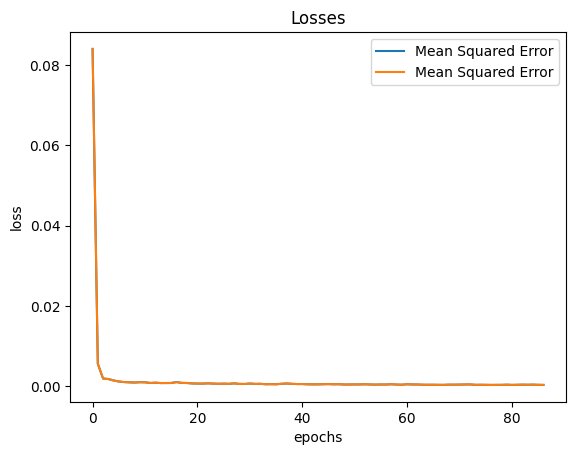

In [ ]:
plt.plot(history["loss"])
plt.plot(history["mean_squared_error"])
plt.legend(['Mean Squared Error','Mean Squared Error'])
plt.title("Losses")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

# **Creating testing set**

In [ ]:
# Creating a testing set with 60 time-steps and 1 output
x_test = []
y_test = []

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])
    y_test.append(test_data[i, 0])
x_test, y_test = np.array(x_test), np.array(y_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

In [ ]:
x_test.shape , y_test.shape

((423, 60, 1), (423,))

# **Predicting Testing data**
Once the model is trained, we can use it to make predictions. The predictions will be on the same scale as the normalized input data, so we must apply the inverse transformation to bring the predicted values back to their original scale.

In [ ]:
#inverse y_test scaling
model.eval()
with torch.no_grad():
    x_test_tensor = torch.tensor(x_test, dtype=torch.float32).to(device)
    predictions = model(x_test_tensor).cpu().numpy()

#inverse predictions scaling
predictions = scaler.inverse_transform(predictions)
predictions.shape

(423, 1)

scaler.inverse_transform(): This function converts the normalized data back to the original scale, allowing us to compare predictions with the actual values.

**Root mean square error**

In [ ]:
#inverse y_test scaling
y_test = scaler.inverse_transform([y_test])

RMSE = np.sqrt(np.mean( y_test - predictions )**2).round(2)
RMSE

np.float64(1.96)

# **Visualize Predictions with The Data**

Finally, we can visualize the model's performance by plotting the original data and the model's predictions. This gives us an insight into how well the model has captured the trends and patterns in the time series.

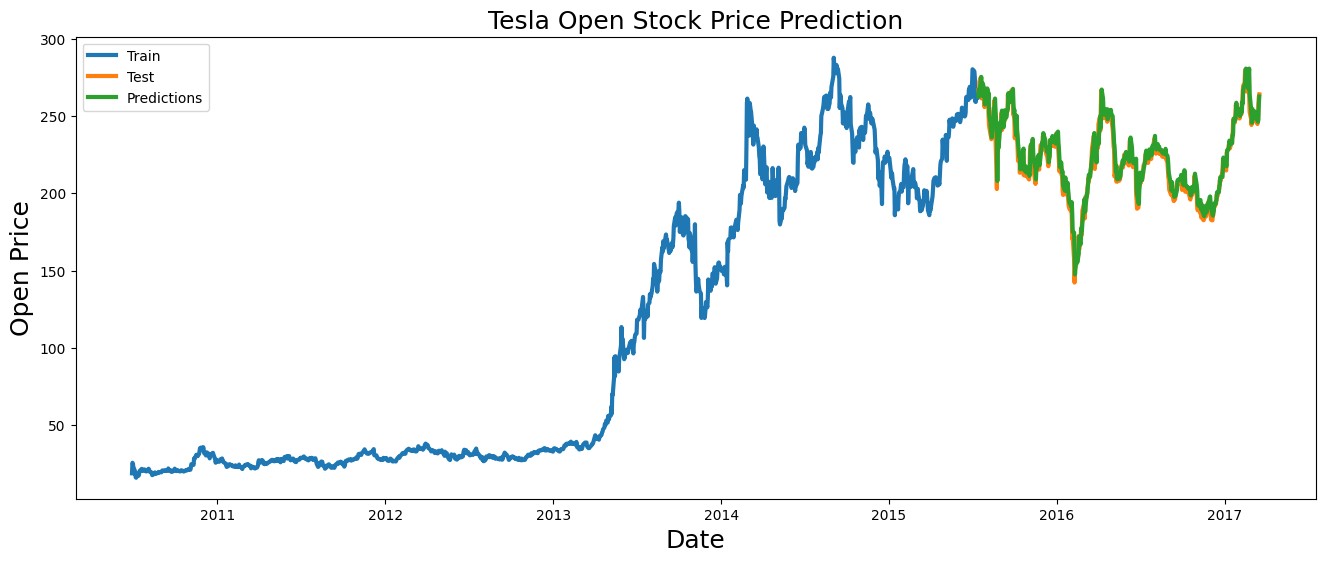

In [ ]:
train = dataset.iloc[:train_size , 0:1]
test = dataset.iloc[train_size: , 0:1]
test['Predictions'] = predictions

plt.figure(figsize=(16,6))
plt.title('Tesla Open Stock Price Prediction' , fontsize=18)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Open Price' ,fontsize=18)
plt.plot(train['Open'],linewidth=3)
plt.plot(test['Open'],linewidth=3)
plt.plot(test["Predictions"],linewidth=3)
plt.legend(['Train','Test','Predictions'])

# Final Questions

Answer these global questions at the end of the lab:

1. What is the purpose of each major stage of the notebook?
   - data loading and visualization
   - normalization with `MinMaxScaler`
   - sliding-window dataset creation
   - LSTM model definition
   - training with early stopping
   - evaluation and visualization of predictions

2. Why do we normalize the stock prices before feeding them into the LSTM?

3. What does the `look_back` parameter (60 time steps) represent, and what would happen if it were much smaller (e.g. 5) or much larger (e.g. 250)?

4. Why does the first LSTM layer need to return the full sequence while the second one only returns its last time step?

5. Why is early stopping here based on the **training loss** rather than a validation loss? What is a risk of this choice?

6. Looking at the final plot (train / test / predictions), does the model seem to capture the overall trend, the short-term fluctuations, both, or neither?

7. Why do we apply `scaler.inverse_transform()` to the predictions before computing the RMSE and plotting the results?

8. What are the limitations of using only the `Open` price as input? What other features (columns) could improve the model?

9. This is a **univariate**, single-step-ahead forecasting setup. How would you adapt the pipeline to predict several days ahead at once (multi-step forecasting)?

10. What practical differences did you notice between the Keras and PyTorch versions of this notebook (e.g. explicit training loop, manual early stopping, handling of `return_sequences`, tensor shapes)?

# Answer

1. Purpose of each major stage of the notebook
* Data loading and visualization: To load the raw time-series data from its source, inspect its structure, check for missing values, and visually identify overall trends, patterns, and seasonality.
* Normalization with MinMaxScaler: To scale values between 0 and 1. Neural networks, including LSTMs, converge much faster and perform more stably when features are on a consistent, small scale.
* Sliding-window dataset creation: To restructure standard unsupervised time-series arrays into a supervised learning format of feature-target pairs ($X, y$$X, y$), where a fixed-length historical sequence (the window) is mapped to the next immediate value.
* LSTM model definition: To build the neural network architecture (layers, hidden states, and activation steps) designed specifically for tracking sequential and long-term dependencies.
* Training with early stopping: To optimize the network's weights iteratively while preventing overfitting. It stops training automatically if the loss stops improving for a specified number of epochs (patience).
* Evaluation and visualization of predictions: To bring predictions back to the original scale using inverse_transform so we can calculate a meaningful performance metric (RMSE) and visually contrast forecasted values with actual values.

2. LSTMs use activation functions like $\tanh$$\tanh$ and sigmoid internally. If input values are very large (e.g., hundreds or thousands of dollars), these functions saturate, leading to vanishing gradients, slow training convergence, or numerical instability. Scaling inputs to a $[0, 1]$$[0, 1]$ range prevents saturation and allows stable, uniform learning rates.

3.
* What it represents: It defines the size of the history window. The model uses the previous 60 trading days (approx. 3 months) to predict the price of the next single day.
* If much smaller (e.g., 5): The model would only look at the past week of trading. It would fail to capture monthly trends, broader cycle developments, or gradual macroeconomic movements.
* If much larger (e.g., 250): The model would analyze an entire year of daily prices. While it can track very long-term patterns, it would significantly increase memory consumption, make training slower, and risk overfitting to historical patterns that are no longer relevant due to market shifts.

4.
* First layer (return_sequences=True): In a stacked architecture, the second LSTM layer expects a sequence of vectors for each time step as its input. Therefore, the first layer must output its hidden states for every time step ($[batch, time\_steps, hidden\_dim]$$[batch, time\_steps, hidden\_dim]$).
* Second layer (return_sequences=False): We are performing a single-step-ahead point forecast. The final dense layers only need a single summary feature vector representing the state of the entire sequence. By taking the hidden state of only the last time step ($out[:, -1, :]$$out[:, -1, :]$), we collapse the time dimension.

5.
* Why: In this specific notebook, there is no separate validation split passed to the training utility, so early stopping is set to monitor the training loss itself.
* Risk: Monitoring training loss does not evaluate generalization. The training loss can continue to decrease while the model begins to overfit (memorize noise). This choice risks stopping the training process too late, resulting in a model that performs poorly on unseen test data.

6. Based on typical outcomes for this setup, the LSTM captures the overall trend exceptionally well but struggles to predict precise daily short-term fluctuations. It often produces a smoothed curve that mimics the true test trajectory with a slight time lag (acting somewhat like a moving average).

7. For RMSE: Computing RMSE on $[0, 1]$$[0, 1]$ scaled data yields a tiny number that doesn't correspond to real-world monetary value. Inverse-scaling restores the values to US Dollars (USD), making the RMSE highly interpretable (e.g., "an average error of $12.50").
For Plotting: We want to plot predictions alongside original stock values to maintain real-world context on the y-axis.

8.
* Limitations: Stock prices are influenced by massive external market dynamics. Using only the Open price treats the market as an isolated system, ignoring intra-day volatility, volume of trading, and external signals.
* Better features: Including Volume, technical indicators (MACD, RSI, Moving Averages), macroeconomic indicators, and sentiment analysis scores from financial news or social media.

9. There are two main ways to adapt the pipeline:

    1. Direct/Vector Output: Modify the final Linear layer to output $N$$N$ neurons instead of 1 (e.g., nn.Linear(16, N)), predicting the next $N$$N$ days simultaneously.
    2. Autoregressive / Recursive: Predict step $t+1$$t+1$, append this prediction to the input window, discard the oldest step, and feed the new window back into the model recursively to predict step $t+2$$t+2$.

10.
* Training Loop: Keras handles optimization implicitly inside .fit(), whereas PyTorch requires writing an explicit nested training loop (zeroing gradients, forward pass, loss calculation, backward pass, and optimizer step).
* Early Stopping: Keras has an out-of-the-box EarlyStopping callback. In PyTorch, we implement it manually by saving a deepcopy of the model's state dictionary when a lower loss is achieved.
* Sequence Output Handling: Keras relies on the return_sequences=True/False layer flag. PyTorch LSTMs always output the entire sequence, and we manually index the final dimension slice (out[:, -1, :]) to simulate return_sequences=False.

**Additional Question**

Airline Passenger Dataset is a dataset which contains the monthly number of passengers from 1949 to 1960. The dataset is accessible via a URL, and we use pandas.read_csv to load it. The dataset contains two columns, but we only focus on the second column, which holds the passenger numbers.

Propose a model based on LSTM (in PyTorch, following the same steps as above: scaling, sliding-window creation, `LSTMForecaster`, training loop with early stopping, and RMSE evaluation) to predict airline passenger numbers using this Dataset.

In [ ]:
# Load Airline Passenger dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
data = pd.read_csv(url, usecols=[1])
data = data.values.astype('float32')